평가


/var/folders/hg/t1mxsq517218n1_8fyrmzqs80000gn/T/ipykernel_17679/2317990252.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("./best_model.pth", 

✅ Model loaded successfully! Ready for inference.

================= 📊 Test Performance =================
✅ Test Accuracy: 99.02%
✅ Test F1 Score (macro): 0.9900


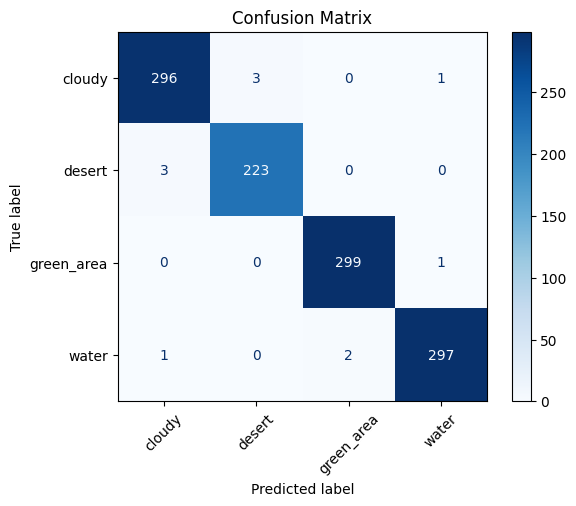

In [2]:
import os, torch
import torch.nn as nn
from torchvision import transforms, datasets
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 1️⃣ 경로 설정
# =========================================================
test_dir = "./test"
model_path = "./best_model.pth"

# =========================================================
# 2️⃣ 테스트 데이터셋 정의
# =========================================================
transform_test = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
	transforms.Resize(
	(128, 128),
	interpolation=InterpolationMode.BICUBIC),
	transforms.ToTensor(),
	transforms.Normalize(mean = [0.4002, 0.4313, 0.4276], std = [0.2648, 0.1987, 0.1455])
])

test_dataset = datasets.ImageFolder(test_dir, transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# =========================================================
# 3️⃣ KumarCNN 모델 정의 (학습 시와 동일)
# =========================================================
class KumarCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(KumarCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=0),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 128, kernel_size=3, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 30 * 30, 512),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(0.3),
            nn.BatchNorm1d(512),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# =========================================================
# 4️⃣ 모델 로드
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 1️⃣ 모델 선언 (서버에서 저장했던 구조와 동일해야 함)
model = KumarCNN(num_classes=4).to(device)

# 2️⃣ state_dict 로드
state_dict = torch.load("./best_model.pth", map_location=device)
model.load_state_dict(state_dict)

# 3️⃣ 평가 모드 전환
model.eval()

print("✅ Model loaded successfully! Ready for inference.")


# =========================================================
# 5️⃣ 테스트 평가
# =========================================================
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# =========================================================
# 6️⃣ 성능 지표 출력
# =========================================================
accuracy = np.mean(np.array(y_true) == np.array(y_pred))
f1 = f1_score(y_true, y_pred, average="macro")

print("\n================= 📊 Test Performance =================")
print(f"✅ Test Accuracy: {accuracy*100:.2f}%")
print(f"✅ Test F1 Score (macro): {f1:.4f}")
print("========================================================")

# =========================================================
# 7️⃣ Confusion Matrix 시각화
# =========================================================
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
